# 🌍 Human Development Index (HDI) Predictor
### End-to-End Machine Learning Project
---

## Epic 1: Environment Setup & Package Installation

In [1]:
# Verify all packages are installed correctly
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import flask
import joblib

print('numpy     :', np.__version__)
print('pandas    :', pd.__version__)
print('matplotlib:', matplotlib.__version__)
print('seaborn   :', sns.__version__)
print('sklearn   :', sklearn.__version__)
print('flask     :', flask.__version__)
print('joblib    :', joblib.__version__)

print('\n✅ All packages loaded successfully!')

Matplotlib is building the font cache; this may take a moment.


numpy     : 2.5.0
pandas    : 3.0.3
matplotlib: 3.11.0
seaborn   : 0.13.2
sklearn   : 1.9.0
flask     : 3.1.3
joblib    : 1.5.3

✅ All packages loaded successfully!


C:\Users\Teja\AppData\Local\Temp\ipykernel_16820\3092459106.py:15: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Flask 3.2. Use feature detection or 'importlib.metadata.version("flask")' instead.
  print('flask     :', flask.__version__)


## Epic 2: Importing Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Epic 3: Dataset Download & Understanding

In [3]:
# Load the dataset
df = pd.read_csv('data/hdi_dataset.csv')

print('Dataset Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())

Dataset Shape: (195, 880)

Column Names:
['ISO3', 'Country', 'Human Development Groups', 'UNDP Developing Regions', 'HDI Rank (2021)', 'Human Development Index (1990)', 'Human Development Index (1991)', 'Human Development Index (1992)', 'Human Development Index (1993)', 'Human Development Index (1994)', 'Human Development Index (1995)', 'Human Development Index (1996)', 'Human Development Index (1997)', 'Human Development Index (1998)', 'Human Development Index (1999)', 'Human Development Index (2000)', 'Human Development Index (2001)', 'Human Development Index (2002)', 'Human Development Index (2003)', 'Human Development Index (2004)', 'Human Development Index (2005)', 'Human Development Index (2006)', 'Human Development Index (2007)', 'Human Development Index (2008)', 'Human Development Index (2009)', 'Human Development Index (2010)', 'Human Development Index (2011)', 'Human Development Index (2012)', 'Human Development Index (2013)', 'Human Development Index (2014)', 'Human Developm

In [4]:
# Preview first few rows
df.head()

,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728,0.739,0.742,0.748,0.755,...,49.56,49.68,55.49,59.76,64.95,75.61,65.97,68.95,68.95,68.95


In [5]:
# Basic info
print('Data Types:')
print(df.dtypes[:10])  # show first 10
print('\nNull Value Counts (first 10 cols):')
print(df.isnull().sum()[:10])

Data Types:
ISO3                                  str
Country                               str
Human Development Groups              str
UNDP Developing Regions               str
HDI Rank (2021)                   float64
Human Development Index (1990)    float64
Human Development Index (1991)    float64
Human Development Index (1992)    float64
Human Development Index (1993)    float64
Human Development Index (1994)    float64
dtype: object

Null Value Counts (first 10 cols):
ISO3                               0
Country                            0
Human Development Groups           4
UNDP Developing Regions           44
HDI Rank (2021)                    4
Human Development Index (1990)    54
Human Development Index (1991)    54
Human Development Index (1992)    54
Human Development Index (1993)    54
Human Development Index (1994)    54
dtype: int64


In [6]:
# HDI tier distribution
print('HDI Group Distribution:')
print(df['Human Development Groups'].value_counts())
print('\nSample Countries per Group:')
print(df.groupby('Human Development Groups')['Country'].apply(lambda x: x.head(3).tolist()))

HDI Group Distribution:
Human Development Groups
Very High    66
High         49
Medium       44
Low          32
Name: count, dtype: int64

Sample Countries per Group:
Human Development Groups
High            [Albania, Armenia, Antigua and Barbuda]
Low                       [Afghanistan, Burundi, Benin]
Medium                     [Angola, Bangladesh, Belize]
Very High    [Andorra, United Arab Emirates, Argentina]
Name: Country, dtype: object


## Epic 3b: Data Visualization & Analysis (EDA)

In [7]:
# Select key columns for analysis
key_cols = [
    'Country',
    'Human Development Groups',
    'HDI Rank (2021)',
    'Human Development Index (2021)',
    'Life Expectancy at Birth (2021)',
    'Mean Years of Schooling (2021)',
    'Expected Years of Schooling (2021)',
    'Gross National Income Per Capita (2021)'
]

# Check which columns actually exist (names may vary slightly)
available = [c for c in df.columns if any(k.lower() in c.lower() for k in 
             ['human development groups', 'hdi rank', 'human development index', 
              'life expectancy', 'mean years', 'expected years', 'gross national'])]
print('Relevant columns found:')
for c in available:
    print(' -', c)

Relevant columns found:
 - Human Development Groups
 - HDI Rank (2021)
 - Human Development Index (1990)
 - Human Development Index (1991)
 - Human Development Index (1992)
 - Human Development Index (1993)
 - Human Development Index (1994)
 - Human Development Index (1995)
 - Human Development Index (1996)
 - Human Development Index (1997)
 - Human Development Index (1998)
 - Human Development Index (1999)
 - Human Development Index (2000)
 - Human Development Index (2001)
 - Human Development Index (2002)
 - Human Development Index (2003)
 - Human Development Index (2004)
 - Human Development Index (2005)
 - Human Development Index (2006)
 - Human Development Index (2007)
 - Human Development Index (2008)
 - Human Development Index (2009)
 - Human Development Index (2010)
 - Human Development Index (2011)
 - Human Development Index (2012)
 - Human Development Index (2013)
 - Human Development Index (2014)
 - Human Development Index (2015)
 - Human Development Index (2016)
 - Human De

In [8]:
# Build working dataframe with the right column names
hdi_col    = [c for c in df.columns if 'Human Development Index' in c and '2021' in c][0]
le_col     = [c for c in df.columns if 'Life Expectancy' in c and '2021' in c][0]
mys_col    = [c for c in df.columns if 'Mean Years of Schooling' in c and '2021' in c][0]
eys_col    = [c for c in df.columns if 'Expected Years of Schooling' in c and '2021' in c][0]
gni_col    = [c for c in df.columns if 'Gross National Income' in c and '2021' in c][0]
group_col  = 'Human Development Groups'

print('Using columns:')
print(f'  HDI Score  : {hdi_col}')
print(f'  Life Exp   : {le_col}')
print(f'  Mean School: {mys_col}')
print(f'  Exp School : {eys_col}')
print(f'  GNI        : {gni_col}')
print(f'  Group      : {group_col}')

Using columns:
  HDI Score  : Human Development Index (2021)
  Life Exp   : Life Expectancy at Birth (2021)
  Mean School: Mean Years of Schooling (2021)
  Exp School : Expected Years of Schooling (2021)
  GNI        : Gross National Income Per Capita (2021)
  Group      : Human Development Groups


In [9]:
# Create clean working dataframe
df_clean = df[['Country', group_col, hdi_col, le_col, mys_col, eys_col, gni_col]].copy()
df_clean.columns = ['Country', 'HDI_Group', 'HDI_Score', 'Life_Expectancy', 
                    'Mean_Years_Schooling', 'Expected_Years_Schooling', 'GNI_Per_Capita']
df_clean = df_clean.dropna()
print('Clean dataset shape:', df_clean.shape)
df_clean.head()

Clean dataset shape: (191, 7)


,Country,HDI_Group,HDI_Score,Life_Expectancy,Mean_Years_Schooling,Expected_Years_Schooling,GNI_Per_Capita
0,Afghanistan,Low,0.478,61.9824,2.985070,10.263844,1824.190915
1,Angola,Medium,0.586,61.6434,5.417391,12.172100,5465.617791
2,Albania,High,0.796,76.4626,11.286455,14.448000,14131.110390
3,Andorra,Very High,0.858,80.3684,10.555120,13.300239,51166.626610
4,United Arab Emirates,Very High,0.911,78.7104,12.694030,15.717690,62573.591810


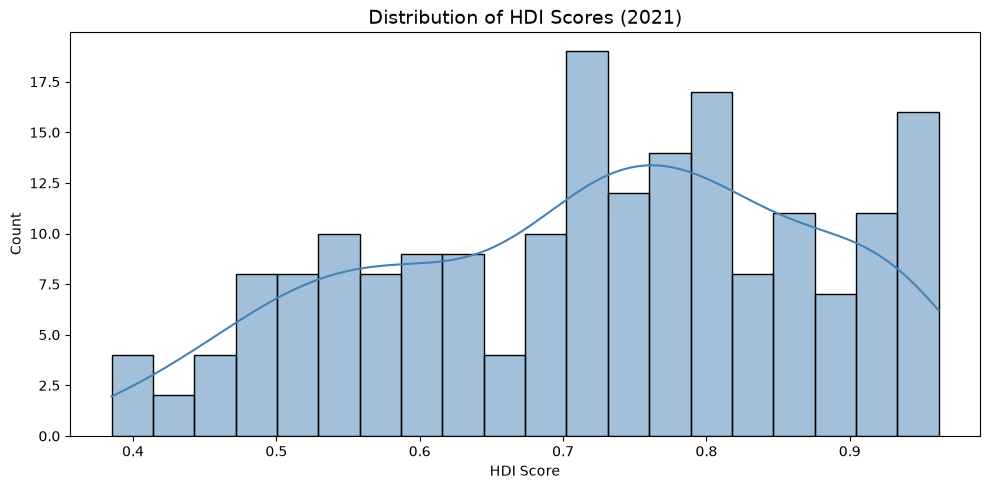

In [10]:
# 1. Distribution Plot - HDI Score
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['HDI_Score'], kde=True, color='steelblue', bins=20)
plt.title('Distribution of HDI Scores (2021)', fontsize=14)
plt.xlabel('HDI Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

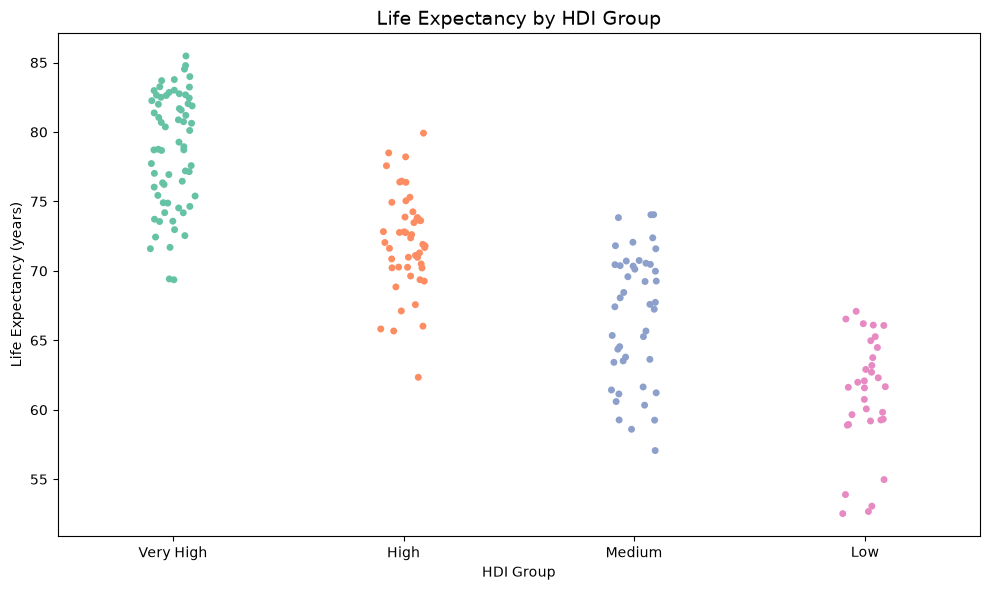

In [11]:
# 2. Strip Plot - Life Expectancy by HDI Group
plt.figure(figsize=(10, 6))
order = ['Very High', 'High', 'Medium', 'Low']
sns.stripplot(data=df_clean, x='HDI_Group', y='Life_Expectancy', 
              order=order, palette='Set2', jitter=True, size=5)
plt.title('Life Expectancy by HDI Group', fontsize=14)
plt.xlabel('HDI Group')
plt.ylabel('Life Expectancy (years)')
plt.tight_layout()
plt.show()

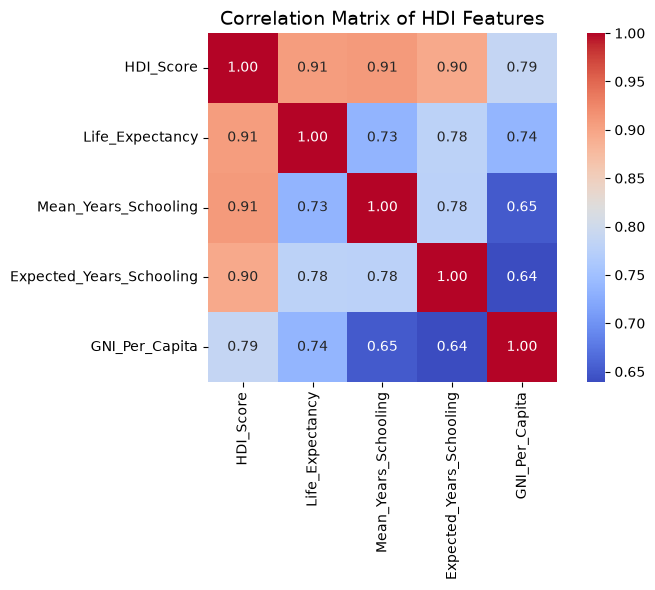

In [12]:
# 3. Heatmap - Correlation Matrix
plt.figure(figsize=(8, 6))
numeric_df = df_clean[['HDI_Score','Life_Expectancy','Mean_Years_Schooling',
                        'Expected_Years_Schooling','GNI_Per_Capita']]
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of HDI Features', fontsize=14)
plt.tight_layout()
plt.show()

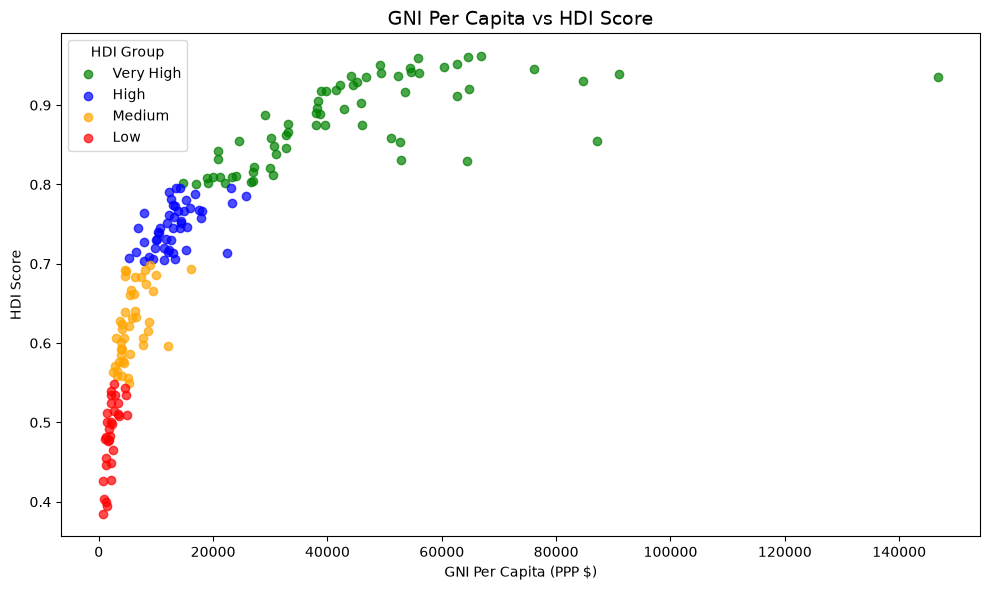

In [13]:
# 4. Scatter Plot - GNI vs HDI Score
plt.figure(figsize=(10, 6))
colors = {'Very High':'green', 'High':'blue', 'Medium':'orange', 'Low':'red'}
for group in ['Very High', 'High', 'Medium', 'Low']:
    subset = df_clean[df_clean['HDI_Group'] == group]
    plt.scatter(subset['GNI_Per_Capita'], subset['HDI_Score'], 
                label=group, color=colors[group], alpha=0.7)
plt.title('GNI Per Capita vs HDI Score', fontsize=14)
plt.xlabel('GNI Per Capita (PPP $)')
plt.ylabel('HDI Score')
plt.legend(title='HDI Group')
plt.tight_layout()
plt.show()

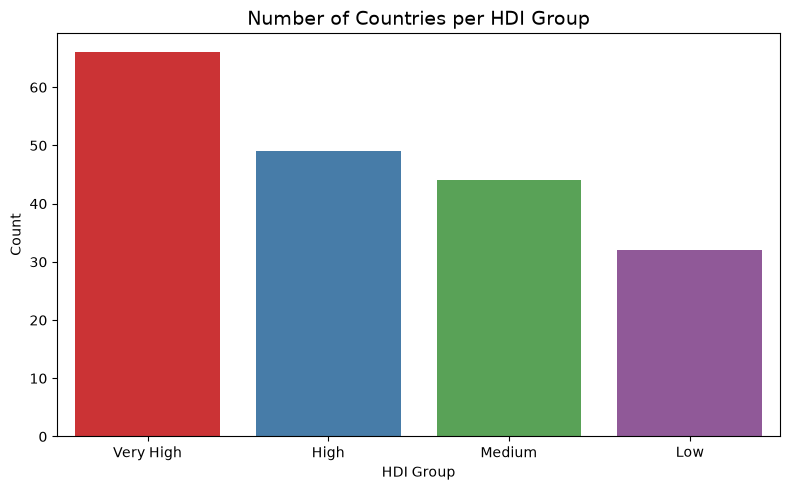

In [14]:
# 5. Bar Plot - HDI Group Counts
plt.figure(figsize=(8, 5))
order = ['Very High', 'High', 'Medium', 'Low']
counts = df_clean['HDI_Group'].value_counts().reindex(order)
sns.barplot(x=counts.index, y=counts.values, palette='Set1')
plt.title('Number of Countries per HDI Group', fontsize=14)
plt.xlabel('HDI Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Epic 4: Data Preprocessing & Feature Engineering

In [15]:
# Features (X) and Target (y)
feature_cols = ['Life_Expectancy', 'Mean_Years_Schooling', 
                'Expected_Years_Schooling', 'GNI_Per_Capita']

X = df_clean[feature_cols].copy()
y = df_clean['HDI_Score'].copy()

print('Features shape:', X.shape)
print('Target shape  :', y.shape)
print('\nFeature statistics:')
print(X.describe())

Features shape: (191, 4)
Target shape  : (191,)

Feature statistics:
       Life_Expectancy  Mean_Years_Schooling  Expected_Years_Schooling  \
count        191.00000            191.000000                191.000000   
mean          71.31286              8.986916                 13.534658   
std            7.64596              3.173693                  2.923911   
min           52.52540              2.114962                  5.542510   
25%           65.74720              6.251659                 11.601258   
50%           71.69400              9.306864                 13.404920   
75%           76.69930             11.497702                 15.623665   
max           85.47340             14.090967                 21.054590   

       GNI_Per_Capita  
count      191.000000  
mean     20249.088223  
std      21825.277076  
min        731.786709  
25%       4592.919612  
50%      12306.341000  
75%      30079.789725  
max     146829.700600  


In [16]:
# Label encode HDI Group for reference (not used in regression)
le = LabelEncoder()
df_clean['HDI_Group_Encoded'] = le.fit_transform(df_clean['HDI_Group'])
print('Label Encoding mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} → {i}')

Label Encoding mapping:
  High → 0
  Low → 1
  Medium → 2
  Very High → 3


In [19]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaled features (first 3 rows):')
print(X_scaled[:3])

Scaled features (first 3 rows):
[[-1.22351958 -1.89609372 -1.12158329 -0.84641859]
 [-1.26797325 -1.12767882 -0.46722998 -0.67913563]
 [ 0.6752944   0.72646654  0.31319081 -0.28105286]]


## Epic 5: Train/Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Training set  : {X_train.shape[0]} samples')
print(f'Testing set   : {X_test.shape[0]} samples')
print(f'Total         : {X_train.shape[0] + X_test.shape[0]} samples')

Training set  : 152 samples
Testing set   : 39 samples
Total         : 191 samples


## Epic 6: Fitting the Model (Linear Regression)

In [21]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print('✅ Model trained successfully!')
print('\nModel Coefficients:')
for name, coef in zip(feature_cols, model.coef_):
    print(f'  {name}: {coef:.4f}')
print(f'Intercept: {model.intercept_:.4f}')

✅ Model trained successfully!

Model Coefficients:
  Life_Expectancy: 0.0489
  Mean_Years_Schooling: 0.0571
  Expected_Years_Schooling: 0.0394
  GNI_Per_Capita: 0.0195
Intercept: 0.7213


In [22]:
# Evaluate the model
y_pred = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('=== Model Evaluation ===')
print(f'Mean Squared Error  (MSE) : {mse:.4f}')
print(f'Mean Absolute Error (MAE) : {mae:.4f}')
print(f'R-Squared Score     (R²)  : {r2:.4f}')

if r2 >= 0.9:
    print('\n✅ Excellent model performance (R² ≥ 0.90)')
elif r2 >= 0.75:
    print('\n✅ Good model performance (R² ≥ 0.75)')
else:
    print('\n⚠️  Model may need improvement')

=== Model Evaluation ===
Mean Squared Error  (MSE) : 0.0005
Mean Absolute Error (MAE) : 0.0177
R-Squared Score     (R²)  : 0.9808

✅ Excellent model performance (R² ≥ 0.90)


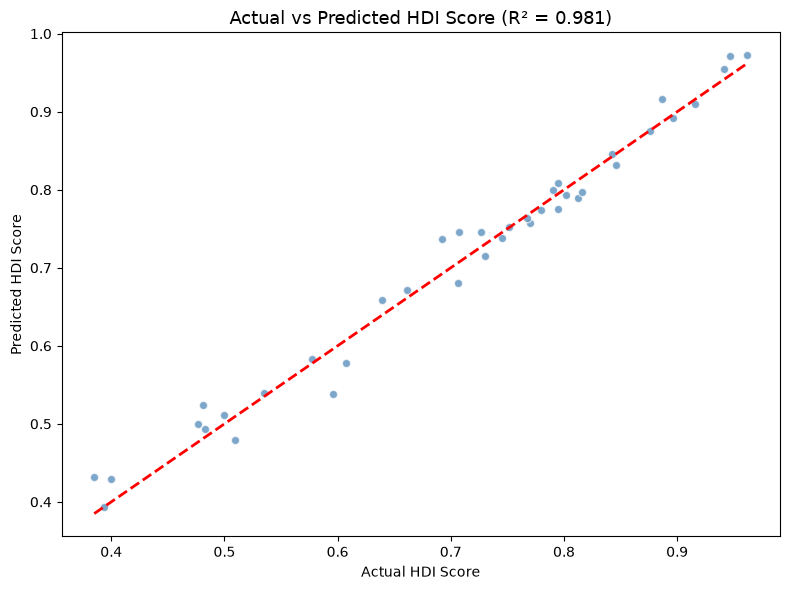

In [23]:
# Predicted vs Actual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual HDI Score')
plt.ylabel('Predicted HDI Score')
plt.title(f'Actual vs Predicted HDI Score (R² = {r2:.3f})', fontsize=13)
plt.tight_layout()
plt.show()

## Epic 7: Saving the Model

In [24]:
import os
os.makedirs('models', exist_ok=True)

# Save model, scaler, and label encoder
joblib.dump(model,  'models/hdi_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le,     'models/label_encoder.pkl')

print('✅ Model saved  → models/hdi_model.pkl')
print('✅ Scaler saved → models/scaler.pkl')
print('✅ Encoder saved→ models/label_encoder.pkl')

✅ Model saved  → models/hdi_model.pkl
✅ Scaler saved → models/scaler.pkl
✅ Encoder saved→ models/label_encoder.pkl


In [26]:
# Quick verification - reload and test
loaded_model  = joblib.load('models/hdi_model.pkl')
loaded_scaler = joblib.load('models/scaler.pkl')

# Test prediction: Norway-like values
test_input = np.array([[82.4, 13.0, 18.2, 64660]])
test_scaled = loaded_scaler.transform(test_input)
prediction  = loaded_model.predict(test_scaled)
print(f'Test prediction (Norway-like input): HDI Score = {prediction[0]:.3f}')
print('✅ Model reload verified!')

Test prediction (Norway-like input): HDI Score = 0.968
✅ Model reload verified!
